Reviewing ERA 5 Patterns

In [1]:
#Necessary packages to load data
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn_som
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
base_dir =r"D:\ERA 5 Data\ERA5_Camden"

In [3]:
var_config = {
    # Original ERA5 variables
    
    "temp": {
        "folder": "Temp",
        "pattern": "era5_2mtemp__*.nc"
    },
    
    "u10": {
        "folder": "U Vector Wind",
        "pattern": "era5_uvector_*.nc"
    },
    
    "v10": {
        "folder": "V Vector Wind",
        "pattern": "era5_vvector_*.nc"
    },
    
    "sp": {
        "folder": "Surface Pressure",
        "pattern": "era5_sp__*.nc"
    },
    
    "dp": {
        "folder": "Dewpoint Temp",
        "pattern": "era5_2m_dew_temp__*.nc"
    },
    
    "k": {
        "folder": "K Index",
        "pattern": "era5_k_index_temp__*.nc"
    },
    
    "sol": {
        "folder": "Sol Rad",
        "pattern": "era5_surface_net_solar_radiation__*.nc"
    },
    # Calculated variables
    "rh": {
        "folder": "Relative Humidity",
        "pattern": "relative_humidity_*.nc"
    },

    "ws": {
        "folder": "Wind Speed",
        "pattern": "wind_speed_*.nc"
    },

    "hi": {
        "folder": "Heat Index",
        "pattern": "heat_index_*.nc"
    },

    "wb": {
        "folder": "Wet Bulb Temp",
        "pattern": "wet_bulb_temperature_*.nc"
    },
}

In [4]:
#Combine each year
def load_variable(var_name):
    config = var_config[var_name]

    path = os.path.join(base_dir, config["folder"], config["pattern"])

    ds = xr.open_mfdataset(
        path,
        combine="by_coords",
        parallel=False  
    )

    # map ERA5 variable name to saved variable name
    var_map = {
        "temp": "t2m",
        "u10": "u10",
        "v10": "v10",
        "sp": "sp",
        "dp": "d2m",
        "k": "kx",
        "sol": "ssr",
        "rh": "relative_humidity",
        "ws" : "wind_speed",
        "hi" : "heat_index",
        "wb" : "wet_bulb_temperature"
    }

    if var_name in var_map and var_map[var_name] in ds.data_vars:
        ds = ds.rename({var_map[var_name]: var_name})
    return ds

In [5]:
#Set city of interest lat and lon 

# Camden: 39.9259, -75.1196
# New Brunswick: 40.4862, -74.4518
# Philadelphia: 39.9526, -75.1652
# Newark: 40.7357, -74.1724
# Trenton: 40.2171, -74.7429
# Paterson: 40.9168, -74.1718
# Elizabeth: 40.6639, -74.2107
# Atlantic City: 39.3643, -74.4229
# Jersey City: 40.7178, -74.0431)

city_lat = 39.9259
city_lon = -75.1196

In [6]:
#Create one daily table per variable, and keep both the mean and max versions in a dictionary

all_daily = {}

for var_name in var_config:
    ds = load_variable(var_name)
    city_var = ds[var_name].sel(latitude=city_lat, longitude=city_lon, method="nearest")

    mean_df = (
        city_var
        .resample(valid_time="1D")
        .mean()
        .to_dataframe(name=var_name)
        .reset_index()
        .rename(columns={"valid_time": "date"})
    )

    max_df = (
        city_var
        .resample(valid_time="1D")
        .max()
        .to_dataframe(name=var_name)
        .reset_index()
        .rename(columns={"valid_time": "date"})
    )

    all_daily[var_name] = {
        "mean": mean_df,
        "max": max_df
    }


In [7]:
combined_df = pd.DataFrame(columns=["date"])

for var_name in list(var_config):
    mean_df = all_daily[var_name]["mean"][["date", var_name]].rename(
        columns={var_name: f"{var_name}_mean"}
    )
    max_df = all_daily[var_name]["max"][["date", var_name]].rename(
        columns={var_name: f"{var_name}_max"}
    )

    combined_df = combined_df.merge(mean_df, on="date", how="outer")
    combined_df = combined_df.merge(max_df, on="date", how="outer")

print(combined_df.head())

        date   temp_mean    temp_max  u10_mean   u10_max  v10_mean   v10_max  \
0 2004-01-01  278.372284  281.487061  3.223092  4.825790 -0.014035  4.201141   
1 2004-01-02  278.190338  281.998291  0.530451  2.226532  1.254314  2.906982   
2 2004-01-03  282.191406  286.991211  0.753728  2.697937  2.183488  2.987854   
3 2004-01-04  283.736694  285.699219  0.484331  2.956024 -0.353329  2.523315   
4 2004-01-05  277.686249  279.808838 -2.180419  0.693573 -1.768015  0.437714   

         sp_mean       sp_max     dp_mean  ...       sol_mean    sol_max  \
0  102078.750000  102525.3125  269.416229  ...  332101.343750  1420928.0   
1  101951.312500  102416.5000  273.323029  ...  153034.671875   914048.0   
2  101303.085938  101736.4375  279.951813  ...  238637.328125  1116672.0   
3  100932.437500  101118.6250  281.770905  ...   68082.664062   351232.0   
4  100773.148438  101130.2500  277.003174  ...   33448.000000   205504.0   

     rh_mean     rh_max   ws_mean    ws_max     hi_mean      h

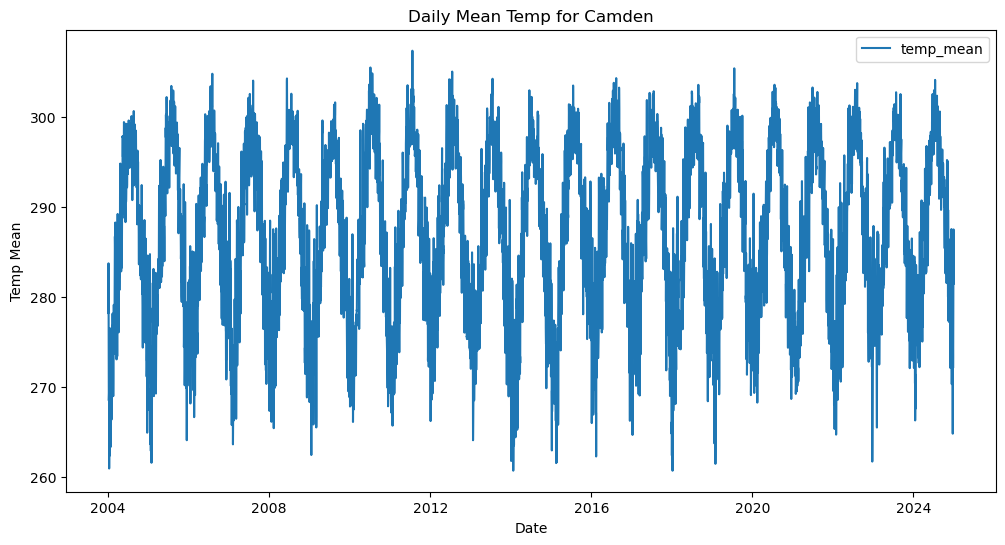

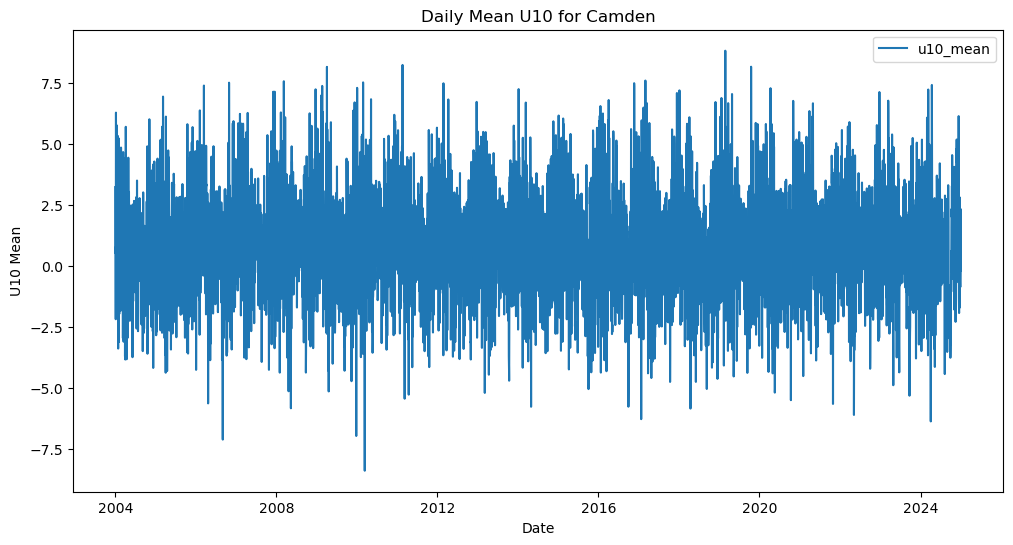

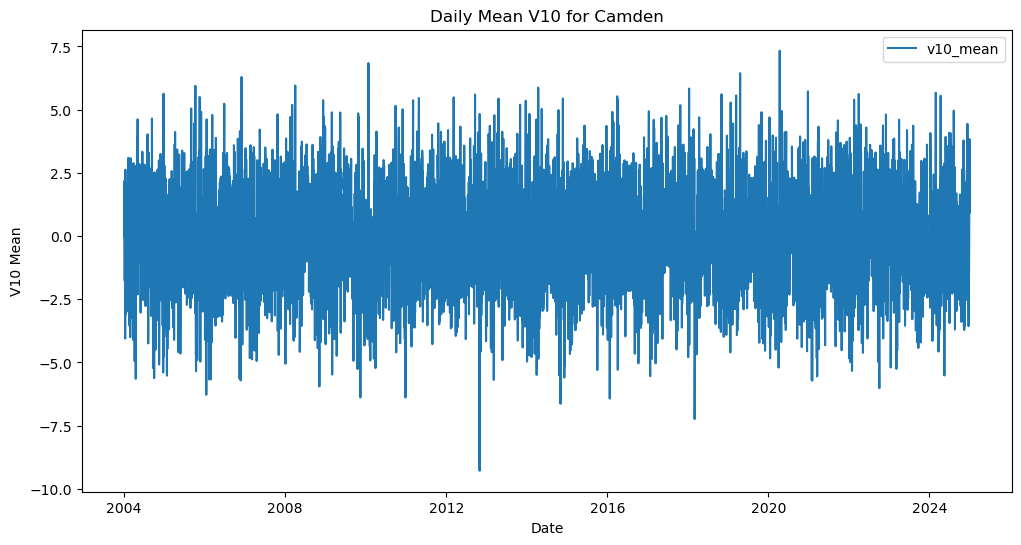

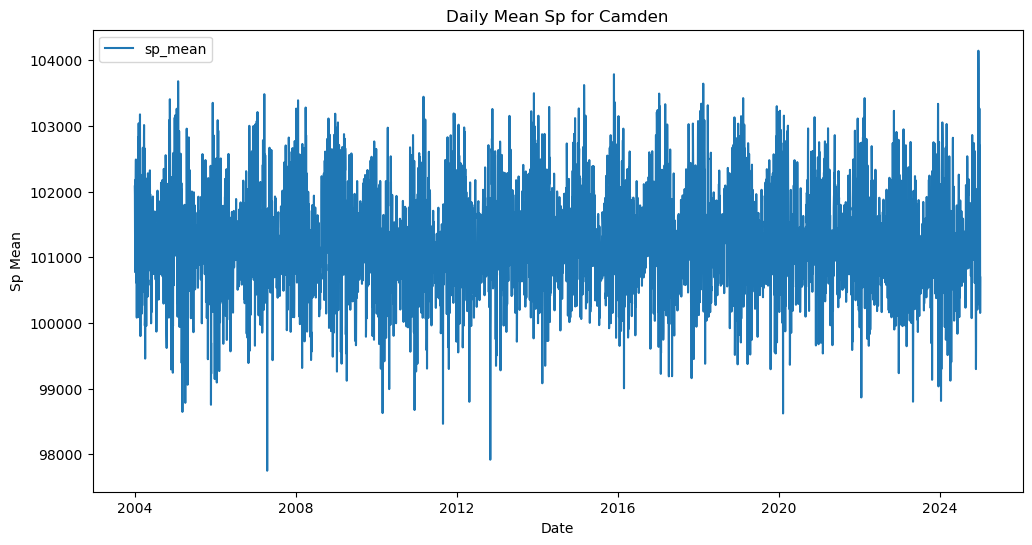

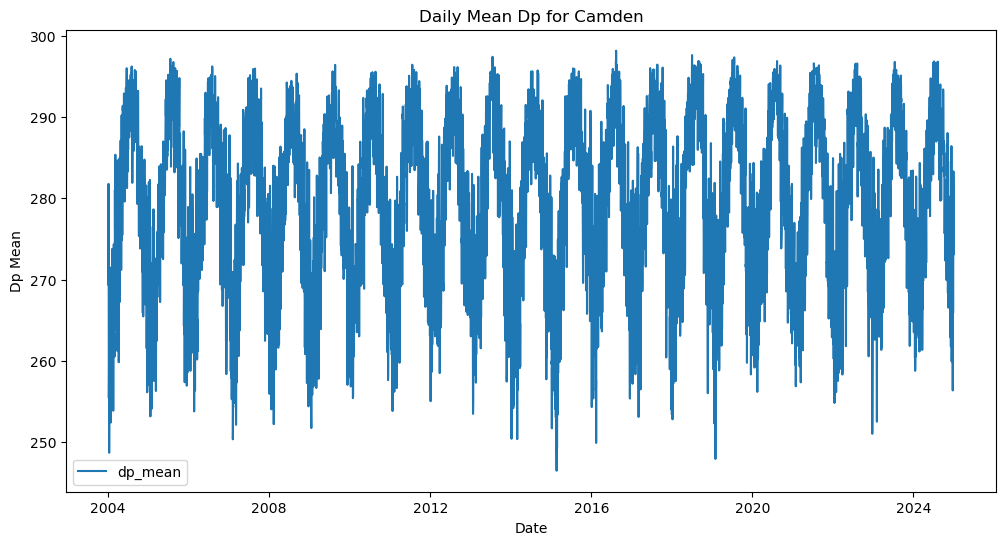

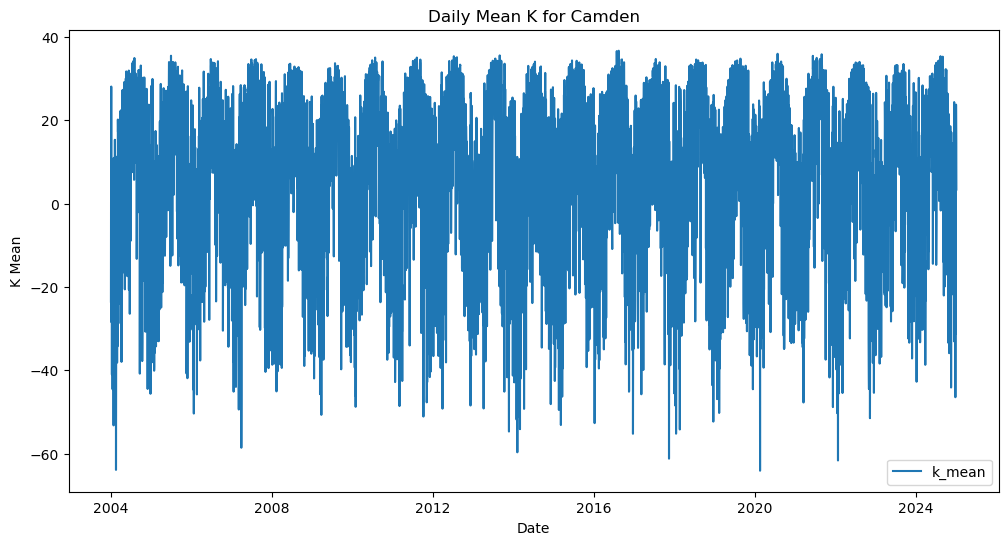

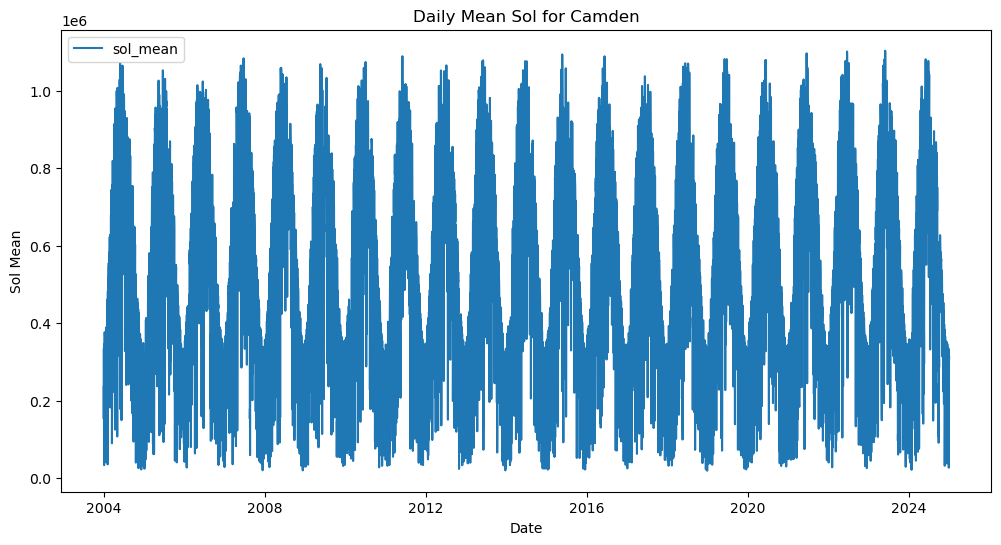

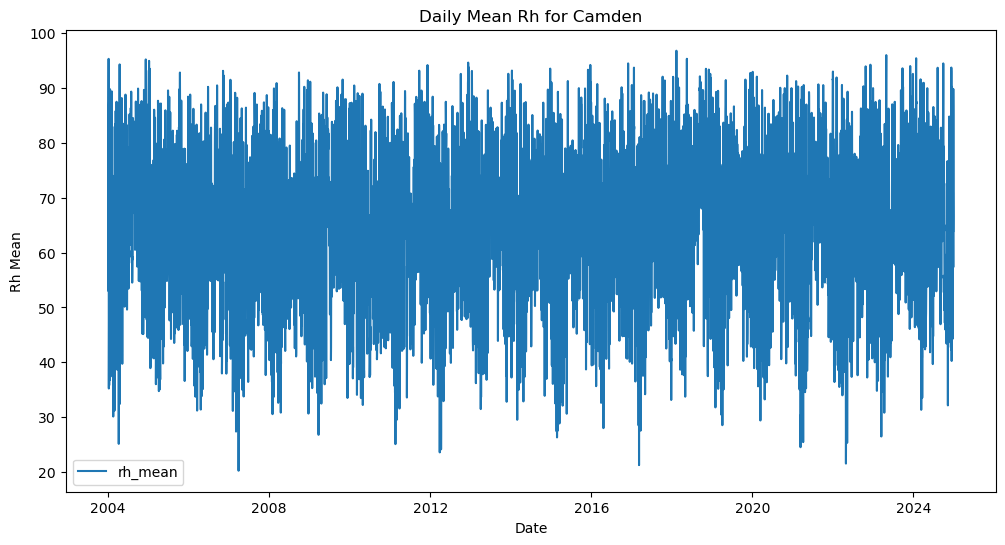

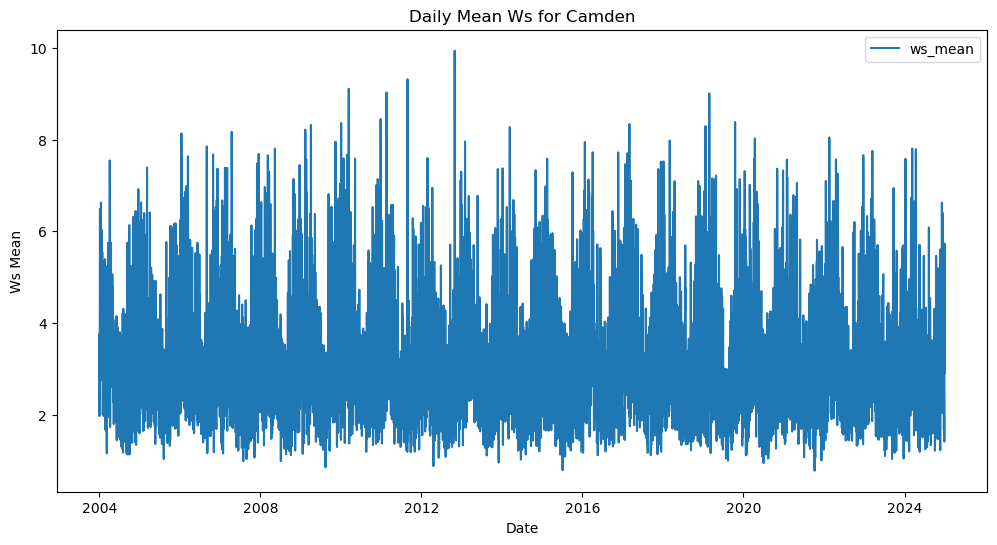

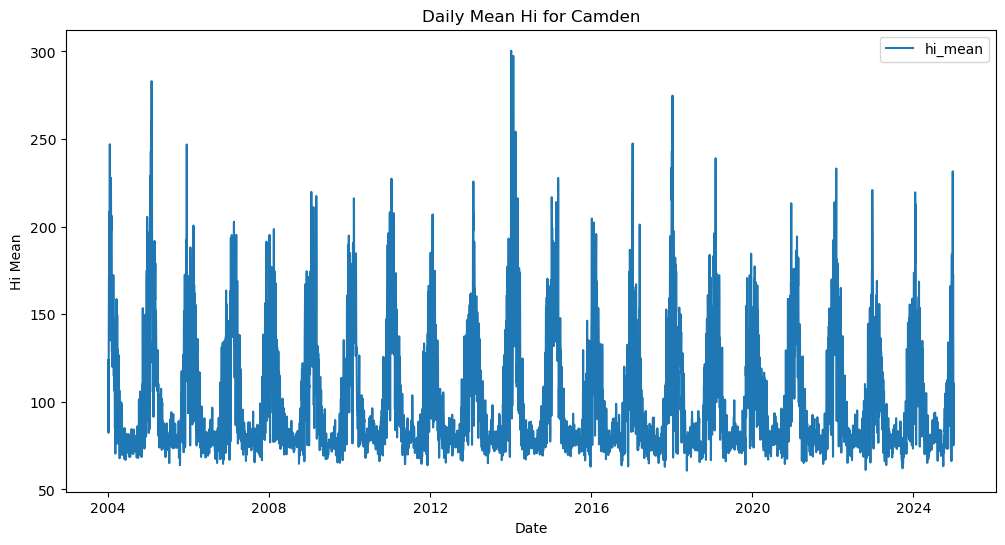

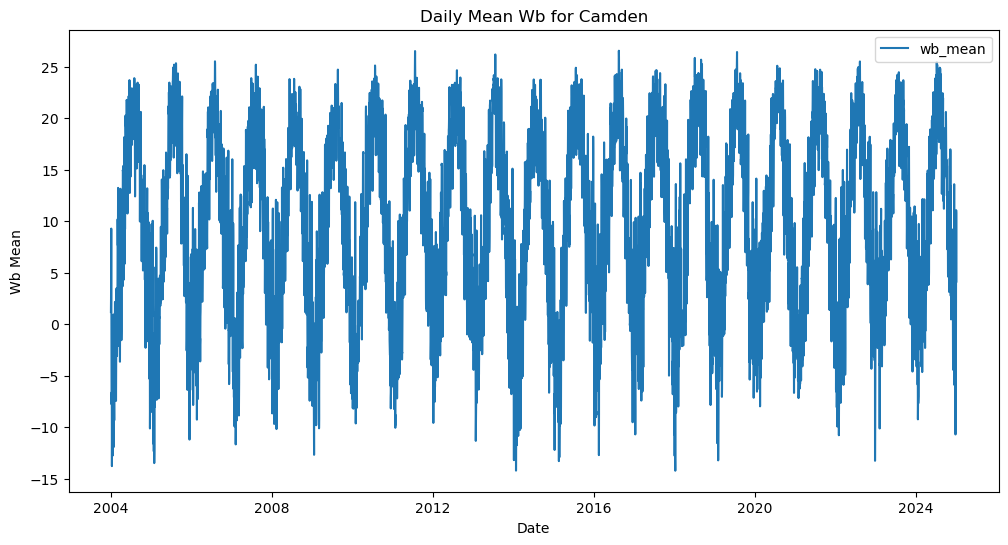

In [8]:
#plot all the daily mean variables for the city of interest
for var_name in combined_df.columns:
    if var_name.endswith("_mean"):
        plt.figure(figsize=(12, 6))
        plt.plot(combined_df["date"], combined_df[var_name], label=var_name)
        plt.title(f"Daily Mean {var_name.replace('_mean', '').capitalize()} for Camden")
        plt.xlabel("Date")
        plt.ylabel(f"{var_name.replace('_mean', '').capitalize()} Mean")
        plt.legend()
        plt.show()

In [9]:
#create quartile profiles for each variable in var_config
#end result will characterize which quartile each variable falls into, for every day in the dataset
#this will allow us to identify extreme events based on the specified quantiles

def add_quartile_columns(df):
    for col in df.columns:
        if col.endswith("_max"):
            var_base = col.replace("_max", "")
            q25 = df[col].quantile(0.25)
            q50 = df[col].quantile(0.50)
            q75 = df[col].quantile(0.75)
            q95 = df[col].quantile(0.95)

            def classify(value, q25=q25, q50=q50, q75=q75, q95=q95):
                if value >= q95:
                    return "Extreme"
                elif value >= q75:
                    return "Q3"
                elif value >= q50:
                    return "Q2"
                elif value >= q25:
                    return "Q1"
                else:
                    return "Below Q1"

            df[f"{var_base}_quartile"] = df[col].apply(classify)
    return df

combined_df = add_quartile_columns(combined_df)

print(combined_df.head())


        date   temp_mean    temp_max  u10_mean   u10_max  v10_mean   v10_max  \
0 2004-01-01  278.372284  281.487061  3.223092  4.825790 -0.014035  4.201141   
1 2004-01-02  278.190338  281.998291  0.530451  2.226532  1.254314  2.906982   
2 2004-01-03  282.191406  286.991211  0.753728  2.697937  2.183488  2.987854   
3 2004-01-04  283.736694  285.699219  0.484331  2.956024 -0.353329  2.523315   
4 2004-01-05  277.686249  279.808838 -2.180419  0.693573 -1.768015  0.437714   

         sp_mean       sp_max     dp_mean  ...  u10_quartile  v10_quartile  \
0  102078.750000  102525.3125  269.416229  ...            Q3            Q3   
1  101951.312500  102416.5000  273.323029  ...            Q1            Q2   
2  101303.085938  101736.4375  279.951813  ...            Q1            Q2   
3  100932.437500  101118.6250  281.770905  ...            Q2            Q2   
4  100773.148438  101130.2500  277.003174  ...      Below Q1      Below Q1   

   sp_quartile  dp_quartile  k_quartile  sol_quart

In [10]:
for col in combined_df.columns:
    if col.startswith("temp") and col.endswith(("_mean", "_max")):
        combined_df[col] = combined_df[col] - 273.15

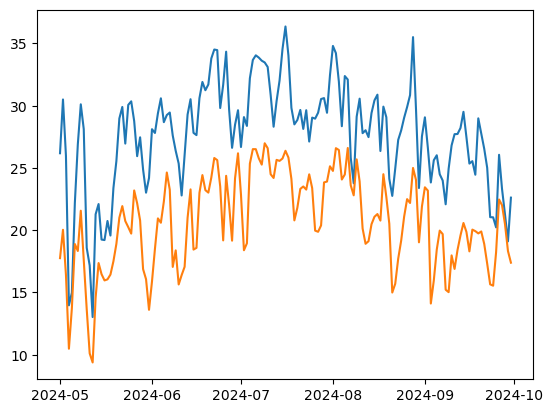

In [11]:
warm_season = (
    combined_df["date"].dt.month.between(5, 9) &
    combined_df["date"].dt.year.between(2024, 2026)
)

plt.plot(
    combined_df.loc[warm_season, "date"],
    combined_df.loc[warm_season, "temp_max"],
    label="Dry Bulb Daily Max"
)

plt.plot(
    combined_df.loc[warm_season, "date"],
    combined_df.loc[warm_season, "wb_max"],
    label="Wet Bulb Daily Max"
)


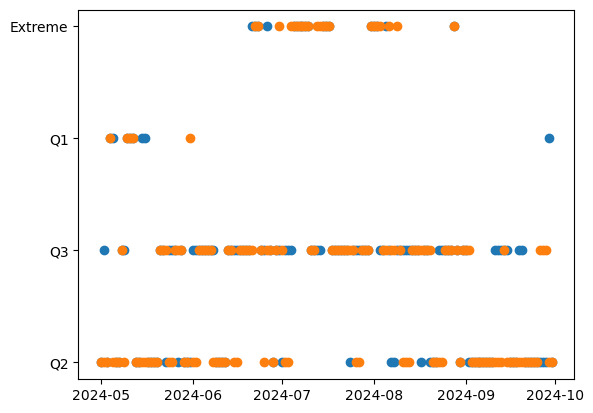

In [12]:
plt.scatter(
    combined_df.loc[warm_season, "date"],
    combined_df.loc[warm_season, "temp_quartile"],
    label="Dry Bulb Daily Quartiles"
)

plt.scatter(
    combined_df.loc[warm_season, "date"],
    combined_df.loc[warm_season, "wb_quartile"],
    label="Wet Bulb Daily Quartiles"
)

In [13]:
def add_quartile_quantity(df):
    quartile_rank = {
        "Below Q1": 0,
        "Q1": 1,
        "Q2": 2,
        "Q3": 3,
        "Extreme": 4
    }

    for col in df.columns:
        if col.endswith("_quartile"):
            var_base = col.replace("_quartile", "")
            df[f"{var_base}_quartile_quantity"] = df[col].map(quartile_rank)

    return df

combined_df = add_quartile_quantity(combined_df)
print(combined_df.head())

        date  temp_mean   temp_max  u10_mean   u10_max  v10_mean   v10_max  \
0 2004-01-01   5.222290   8.337067  3.223092  4.825790 -0.014035  4.201141   
1 2004-01-02   5.040344   8.848297  0.530451  2.226532  1.254314  2.906982   
2 2004-01-03   9.041412  13.841217  0.753728  2.697937  2.183488  2.987854   
3 2004-01-04  10.586700  12.549225  0.484331  2.956024 -0.353329  2.523315   
4 2004-01-05   4.536255   6.658844 -2.180419  0.693573 -1.768015  0.437714   

         sp_mean       sp_max     dp_mean  ...  u10_quartile_quantity  \
0  102078.750000  102525.3125  269.416229  ...                      3   
1  101951.312500  102416.5000  273.323029  ...                      1   
2  101303.085938  101736.4375  279.951813  ...                      1   
3  100932.437500  101118.6250  281.770905  ...                      2   
4  100773.148438  101130.2500  277.003174  ...                      0   

   v10_quartile_quantity  sp_quartile_quantity  dp_quartile_quantity  \
0                   

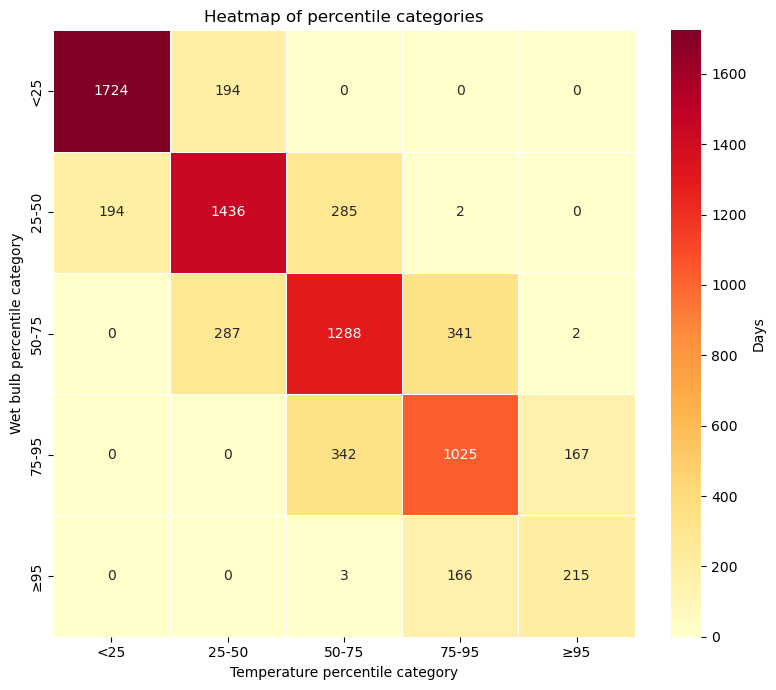

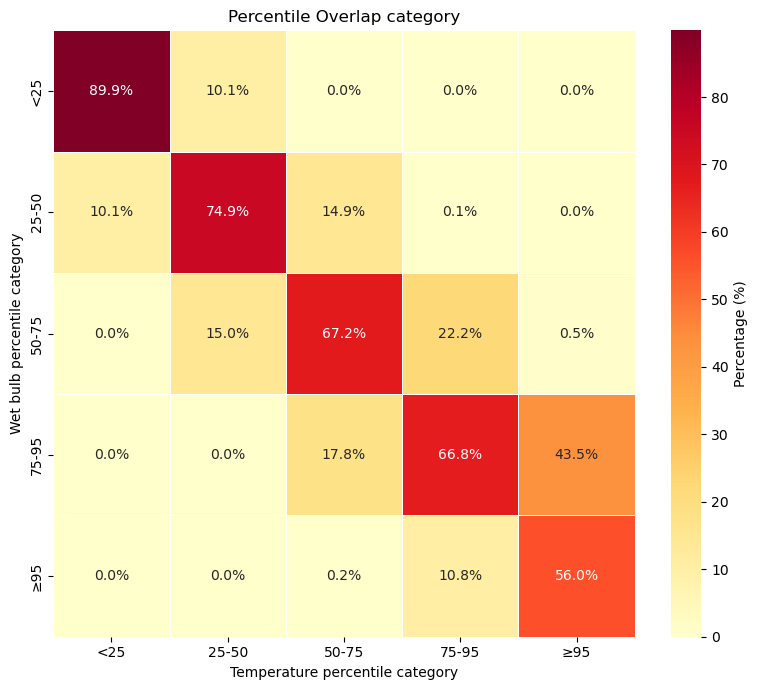

In [14]:
import seaborn as sns

label_map = {
    0: "<25",
    1: "25-50",
    2: "50-75",
    3: "75-95",
    4: "≥95"
}

temp_labels = combined_df["temp_quartile_quantity"].map(label_map)
wb_labels = combined_df["wb_quartile_quantity"].map(label_map)

cat_order = ["<25", "25-50", "50-75", "75-95", "≥95"]

temp_cat = pd.Categorical(temp_labels, categories=cat_order, ordered=True)
wb_cat = pd.Categorical(wb_labels, categories=cat_order, ordered=True)

# rows = wet bulb category, columns = temperature category
# counts how many rows fall into each combination of wet-bulb category and temperature category 
# ie each cell in the output table is the number of days where the wet-bulb percentile category matched one row and the temperature percentile category matched one column.
cross = pd.crosstab(wb_cat, temp_cat)
cross_percent = cross.div(cross.sum(axis=0), axis=1) *100
percent_labels = cross_percent.map(lambda x: f'{x:.1f}%')

# keep the table in the order you want
cross = cross.reindex(index=cat_order, columns=cat_order, fill_value=0)
cross_percent = cross_percent.reindex(index=cat_order, columns=cat_order, fill_value=0)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cross,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar=True,
    cbar_kws={"label": "Days"}
)

plt.xlabel("Temperature percentile category")
plt.ylabel("Wet bulb percentile category")
plt.title("Heatmap of percentile categories")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 7))
sns.heatmap(
    cross_percent,
    annot=percent_labels,
    fmt='',
    cmap="YlOrRd",
    linewidths=0.5,
    cbar=True,
    cbar_kws={'label': 'Percentage (%)'}
)

plt.xlabel('Temperature percentile category')
plt.ylabel('Wet bulb percentile category')
plt.title('Percentile Overlap category')
plt.tight_layout()
plt.show()

In [15]:
#Calculate the difference between two category values
##D=CategoryVar1​−CategoryVar2​
D = combined_df["temp_quartile_quantity"] - combined_df["wb_quartile_quantity"]

D_counts = D.value_counts().sort_index()
D_percent = D.value_counts(normalize=True).sort_index() * 100

D_summary = pd.DataFrame({
    "Count": D_counts,
    "Percent": D_percent
})
print(D_summary)

    Count    Percent
-2      3   0.039108
-1    989  12.892713
 0   5688  74.149394
 1    987  12.866641
 2      4   0.052144


There is no directional bias:

74.1% of observations assigned to the same category.

12.9% of observations placed temperature one category higher than wet-bulb temperature

12.9% placed wet-bulb temperature one category higher than temperature

differences of two categories occurred in fewer than 0.1% of observations

In [16]:
#Root mean square (RMS) is a statistical measure of the magnitude of a varying quantity, calculated as the square root of the arithmetic mean of the squares of the values
# Calculate RMS
rms_db = np.sqrt(np.mean(combined_df["temp_quartile_quantity"].dropna()**2))
print(rms_db)

rms_wb = np.sqrt(np.mean(combined_df["wb_quartile_quantity"].dropna()**2))
print(rms_wb)


rms_db = np.sqrt(np.mean(combined_df["temp_max"]**2))
print(f"RMS: {rms_db}")

rms_wb = np.sqrt(np.mean(combined_df["wb_max"]**2))
print(f"RMS: {rms_wb}")

1.962329365885452
1.962329365885452
RMS: 20.96573829650879
RMS: 15.421055793762207


In [17]:
import statsmodels.api as sm
model_1= sm.OLS(combined_df["temp_max"],combined_df["wb_max"]).fit()
print(model_1.summary())


                                 OLS Regression Results                                
Dep. Variable:               temp_max   R-squared (uncentered):                   0.973
Model:                            OLS   Adj. R-squared (uncentered):              0.973
Method:                 Least Squares   F-statistic:                          2.794e+05
Date:                Sat, 26 Sep 2026   Prob (F-statistic):                        0.00
Time:                        10:15:52   Log-Likelihood:                         -20333.
No. Observations:                7671   AIC:                                  4.067e+04
Df Residuals:                    7670   BIC:                                  4.068e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

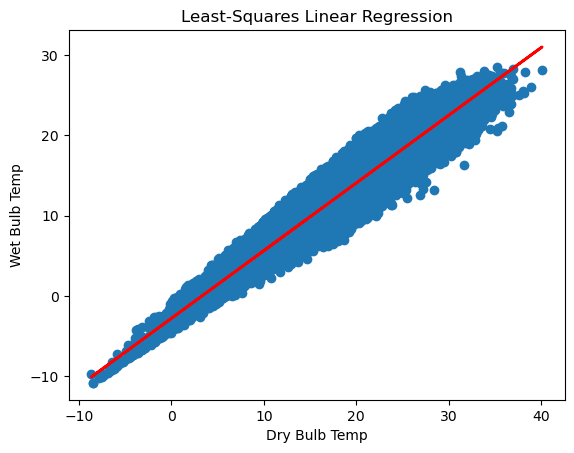

Slope: 0.843
Intercept: -2.786
R²: 0.937
P-value: 0.000e+00
Standard error: 0.002


In [18]:
from scipy.stats import linregress

# Your two variables
x = combined_df["temp_max"]
y = combined_df["wb_max"]

# Least-squares linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)

# Predicted y values
y_pred = slope * x + intercept

# Plot data
plt.plot(x, y, 'o')

# Plot least-squares best-fit line
plt.plot(x, y_pred, color='red', linewidth=2)

plt.xlabel('Dry Bulb Temp')
plt.ylabel('Wet Bulb Temp')
plt.title('Least-Squares Linear Regression')

plt.show()

# Regression statistics
print(f"Slope: {slope:.3f}")
print(f"Intercept: {intercept:.3f}")
print(f"R²: {r_value**2:.3f}")
print(f"P-value: {p_value:.3e}")
print(f"Standard error: {std_err:.3f}")